# Methods and Parameters for Feature Detection: Subsegmentation

## Overview

In this example, we will explore tobac's feature detection methods with a focus on the **subsegmentation** approach for identifying complex atmospheric features. We will compare different feature detection methods to understand when and why to use each one.


The **subsegmentation** method is particularly useful in situations where objects start to be interconnected via filament or bridge-like connections. Subsegmentation breaks these interconnection up with the need to define multiple thresholds.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import datetime

%matplotlib inline

import seaborn as sns
sns.set_context("talk")

import scipy.ndimage
import warnings
warnings.filterwarnings("ignore")

In [2]:
import tobac

mahotas package not available - do not use mahotas options


## Creating Synthetic Test Data

We will create a synthetic 2D field that mimics atmospheric data with multiple features at different scales and intensities. This type of complex field is where subsegmentation methods excel compared to simple thresholding.

The data will contain:
- Multiple features with varying intensities
- Background noise typical of atmospheric data
- Complex spatial structures that challenge simple threshold methods

In [3]:
# Set random seed for reproducibility
np.random.seed(48)

# Create synthetic data resembling atmospheric fields
nx, ny = 300, 300
x = np.linspace(0, 100, nx)
y = np.linspace(0, 100, ny)
X, Y = np.meshgrid(x, y)

# Generate base random field with spatial correlation (like atmospheric turbulence)
rand = np.random.randn(1, ny, nx)
rand_sm = scipy.ndimage.gaussian_filter(rand, sigma=3)

# Add some structured features at different scales
# Large-scale feature
large_feature = 2.0 * np.exp(-((X-30)**2 + (Y-40)**2) / (15**2))
# Medium-scale features
medium_feature1 = 1.4 * np.exp(-((X-32)**2 + (Y-70)**2) / (8**2))
medium_feature2 = 1.2 * np.exp(-((X-15)**2 + (Y-76)**2) / (6**2))
# Small-scale features
small_feature1 = 0.8 * np.exp(-((X-80)**2 + (Y-20)**2) / (4**2))
small_feature2 = 0.9 * np.exp(-((X-60)**2 + (Y-30)**2) / (3**2))

# Combine all features with the noisy background
synthetic_field = (rand_sm[0] + large_feature + medium_feature1 + 
                  medium_feature2 + small_feature1 + small_feature2)

# Create xarray DataArray
darray = xr.DataArray(
    synthetic_field[np.newaxis, :, :],
    dims=("time", "y", "x"),
    coords={
        "y": y,
        "x": x,
        'time': [datetime.datetime(2022, 2, 22)],
    },
    attrs={
        'units': 'arbitrary_units',
        'long_name': 'Synthetic atmospheric field',
        'description': 'Multi-scale features with realistic noise'
    }
)

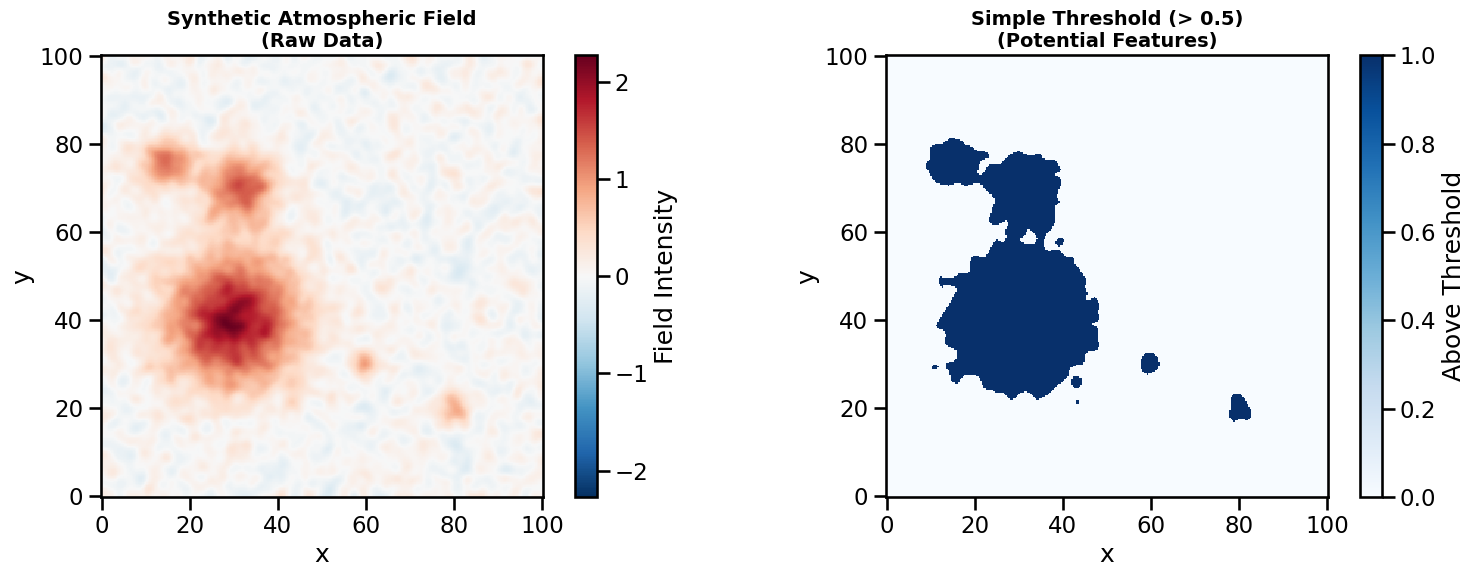

In [4]:
# Visualize the synthetic field
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Raw field
im1 = darray[0].plot(ax=axes[0], cmap='RdBu_r', add_colorbar=False)
axes[0].set_title('Synthetic Atmospheric Field\n(Raw Data)', fontsize=14, fontweight='bold')
axes[0].set_aspect('equal')
plt.colorbar(im1, ax=axes[0], label='Field Intensity')

# Thresholded field to show potential features
threshold = 0.5
im2 = (darray[0] > threshold).plot(ax=axes[1], cmap='Blues', add_colorbar=False)
axes[1].set_title(f'Simple Threshold (> {threshold})\n(Potential Features)', fontsize=14, fontweight='bold')
axes[1].set_aspect('equal')
plt.colorbar(im2, ax=axes[1], label='Above Threshold')

plt.tight_layout()
plt.show()

## Standard Feature Detection Method

Let's start by using tobac's standard feature detection methods. These methods identify features by finding connected regions above a threshold and detecting local maxima within those regions.

### Method 1: Single Threshold Labeling

This is the classic approach where features are identified as local maxima within regions above a single threshold. 

In [5]:
# Standard feature detection with multiple thresholds
labels_standard, features_standard = tobac.feature_detection_multithreshold(
    darray,
    dxy=1.0,  # Grid spacing in km (arbitrary units for this example)
    threshold=0.5,  # Multiple thresholds for feature hierarchy
    min_num=21,
    target='maximum',  # Look for local maxima
    return_labels = True,
)

print(f"Standard method detected {len(features_standard)} features")
print("\nFeature summary:")
print(features_standard[['threshold_value', 'x', 'y', 'num']].round(2))

... using connected components for feature detection
Standard method detected 7 features

Feature summary:
   threshold_value      x      y    num
0              0.5  80.09  19.95    209
1              0.5  43.31  21.40      6
2              0.5  29.19  48.71  12047
3              0.5  43.13  25.95     45
4              0.5  59.73  30.23    148
5              0.5  10.98  29.40     12
6              0.5  39.31  57.79     24


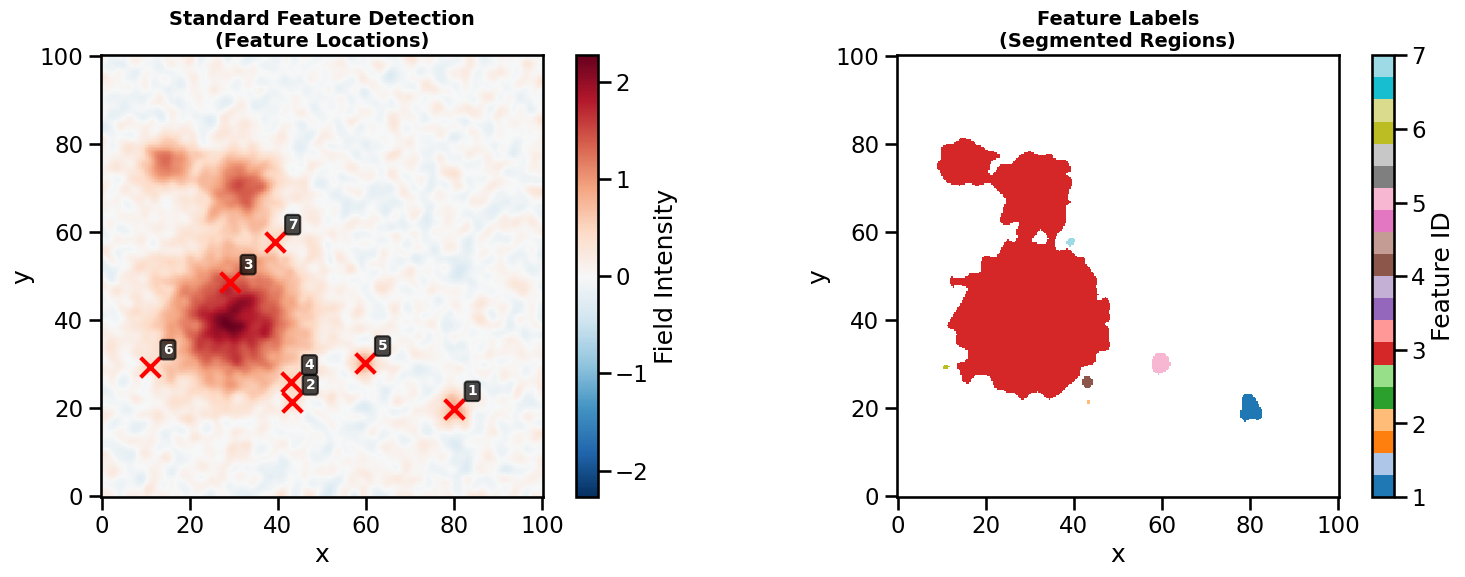

In [6]:
# Visualize the labeled features
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Raw field with detected features overlaid
im1 = darray[0].plot(ax=axes[0], cmap='RdBu_r', add_colorbar=False)
for _, feature in features_standard.iterrows():
    axes[0].scatter(feature['x'], feature['y'], 
                   s=200, c='red', marker='x', linewidth=3)
    axes[0].text(feature['x']+3, feature['y']+3, 
                f"{int(feature['feature'])}", 
                fontsize=10, fontweight='bold', color='white',
                bbox=dict(boxstyle="round,pad=0.2", facecolor='black', alpha=0.7))
axes[0].set_title('Standard Feature Detection\n(Feature Locations)', fontsize=14, fontweight='bold')
axes[0].set_aspect('equal')
plt.colorbar(im1, ax=axes[0], label='Field Intensity')

# Feature labels (segmented regions)
labels_masked = labels_standard.where(labels_standard > 0)
im2 = labels_masked[0].plot(ax=axes[1], cmap='tab20', add_colorbar=False)
axes[1].set_title('Feature Labels\n(Segmented Regions)', fontsize=14, fontweight='bold')
axes[1].set_aspect('equal')
plt.colorbar(im2, ax=axes[1], label='Feature ID')

plt.tight_layout()
plt.show()

### Method 2: Multiple Thresholds Labeling

This is the classic approach where features are identified as local maxima within regions above multiple thresholds. 

In [7]:
# Standard feature detection with multiple thresholds
labels_standard, features_standard = tobac.feature_detection_multithreshold(
    darray,
    dxy=1.0,  # Grid spacing in km (arbitrary units for this example)
    threshold=[0.5,0.7,1.0],  # Multiple thresholds for feature hierarchy
    min_num=21,
    target='maximum',  # Look for local maxima
    return_labels = True,
)

print(f"Standard method detected {len(features_standard)} features")
print("\nFeature summary:")
print(features_standard[['threshold_value', 'x', 'y', 'num']].round(2))

... using connected components for feature detection
... using connected components for feature detection
... using connected components for feature detection
Standard method detected 9 features

Feature summary:
   threshold_value      x      y   num
0              0.5  43.31  21.40     6
1              0.5  43.13  25.95    45
2              0.5  10.98  29.40    12
3              0.5  39.31  57.79    24
4              0.7  80.36  19.95    80
5              0.7  59.74  30.25    67
6              1.0  30.04  40.04  4213
7              1.0  31.65  69.97   709
8              1.0  14.93  75.68   256


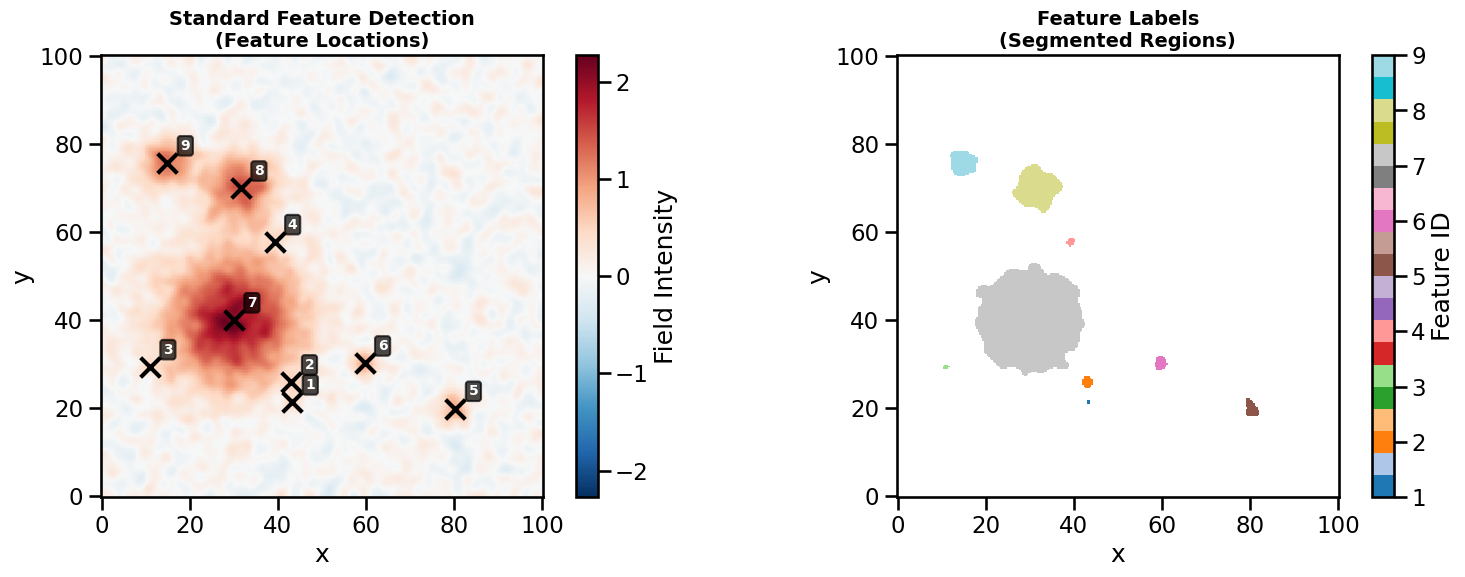

In [8]:
# Visualize the labeled features
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Raw field with detected features overlaid
im1 = darray[0].plot(ax=axes[0], cmap='RdBu_r', add_colorbar=False)
for _, feature in features_standard.iterrows():
    axes[0].scatter(feature['x'], feature['y'], 
                   s=200, c='black', marker='x', linewidth=3)
    axes[0].text(feature['x']+3, feature['y']+3, 
                f"{int(feature['feature'])}", 
                fontsize=10, fontweight='bold', color='white',
                bbox=dict(boxstyle="round,pad=0.2", facecolor='black', alpha=0.7))
axes[0].set_title('Standard Feature Detection\n(Feature Locations)', fontsize=14, fontweight='bold')
axes[0].set_aspect('equal')
plt.colorbar(im1, ax=axes[0], label='Field Intensity')

# Feature labels (segmented regions)
labels_masked = labels_standard.where(labels_standard > 0)
im2 = labels_masked[0].plot(ax=axes[1], cmap='tab20', add_colorbar=False)
axes[1].set_title('Feature Labels\n(Segmented Regions)', fontsize=14, fontweight='bold')
axes[1].set_aspect('equal')
plt.colorbar(im2, ax=axes[1], label='Feature ID')

plt.tight_layout()
plt.show()

## Subsegmentation Method for Complex Features

The **subsegmentation method** uses advanced image segmentation techniques to identify features in complex fields. Instead of simple thresholding, it employs:

1. **Watershed segmentation**: Separates features that might be connected in threshold-based approaches
2. **Marker-based segmentation**: Uses sophisticated marker detection to identify feature centers
3. **Iterative shrinking**: Reduces markers to their most significant points


In [9]:
# Standard feature detection with multiple thresholds
labels_subsegment, features_subsegment = tobac.feature_detection_multithreshold(
    darray,
    dxy=1.0,  # Grid spacing in km (arbitrary units for this example)
    threshold=0.5,  # Multiple thresholds for feature hierarchy
    min_num=21,
    target='maximum',  # Look for local maxima
    return_labels = True,
    # -------------------------------------
    # special options for subsegmentation
    # -------------------------------------
    feature_detection_method = 'subsegmentation',
    marker_method="iterative_shrinking",
    marker_shrinkage_Niter=5,
    marker_shrinkage_dmin=0.2,
)

print(f"Standard method detected {len(features_subsegment)} features")
print("\nFeature summary:")
print(features_subsegment[['threshold_value', 'x', 'y', 'num']].round(2))

... using subsegmentation for feature detection
0 . Shrinking iteration
1 . Shrinking iteration
2 . Shrinking iteration
3 . Shrinking iteration
4 . Shrinking iteration


Standard method detected 6 features

Feature summary:
   threshold_value      x      y   num
0              0.5  30.20  40.24  8685
1              0.5  31.09  68.69  2377
2              0.5  15.51  75.67   965
3              0.5  80.10  19.96   208
4              0.5  59.73  30.24   147
5              0.5  43.14  25.92    44


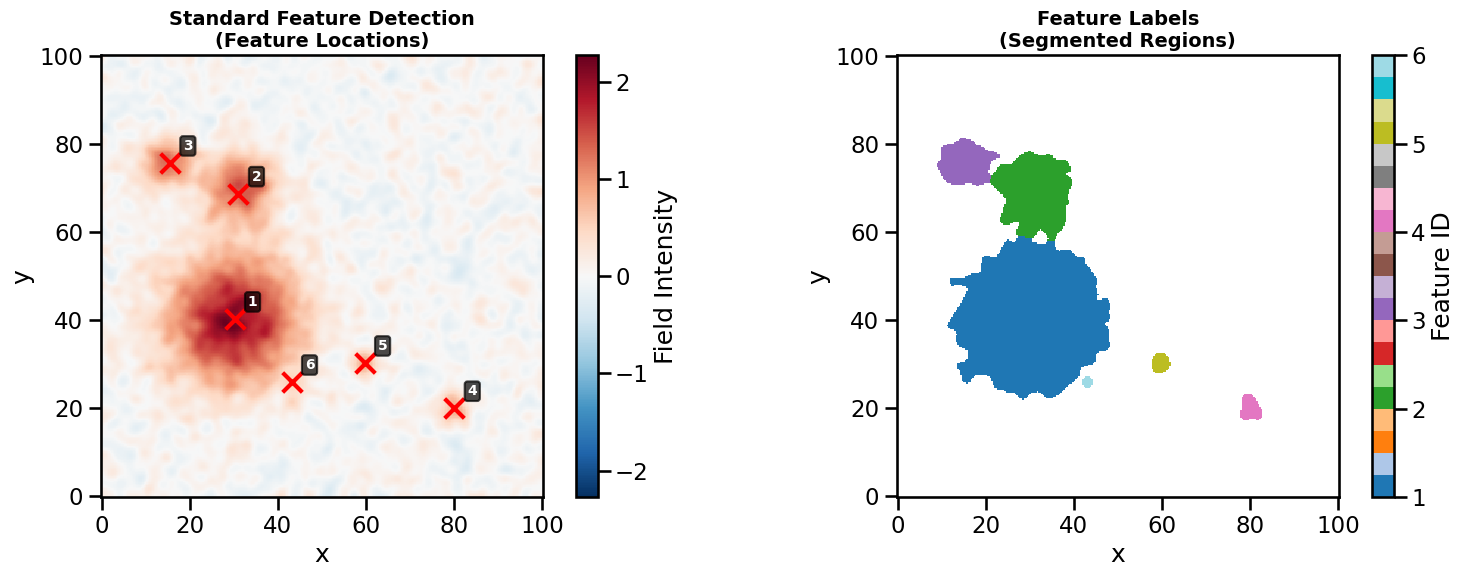

In [10]:
# Visualize the labeled features
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Raw field with detected features overlaid
im1 = darray[0].plot(ax=axes[0], cmap='RdBu_r', add_colorbar=False)
for _, feature in features_subsegment.iterrows():
    axes[0].scatter(feature['x'], feature['y'], 
                   s=200, c='red', marker='x', linewidth=3)
    axes[0].text(feature['x']+3, feature['y']+3, 
                f"{int(feature['feature'])}", 
                fontsize=10, fontweight='bold', color='white',
                bbox=dict(boxstyle="round,pad=0.2", facecolor='black', alpha=0.7))
axes[0].set_title('Standard Feature Detection\n(Feature Locations)', fontsize=14, fontweight='bold')
axes[0].set_aspect('equal')
plt.colorbar(im1, ax=axes[0], label='Field Intensity')

# Feature labels (segmented regions)
labels_masked = labels_subsegment.where(labels_subsegment > 0)
im2 = labels_masked[0].plot(ax=axes[1], cmap='tab20', add_colorbar=False)
axes[1].set_title('Feature Labels\n(Segmented Regions)', fontsize=14, fontweight='bold')
axes[1].set_aspect('equal')
plt.colorbar(im2, ax=axes[1], label='Feature ID')

plt.tight_layout()
plt.show()